# K-Nearest Neighbors (KNN) vs. Radius Neighbors (RNN) — Wine Dataset

**Name:** Arun Bhaskar Gadde

**Course:** 2026 Summer - Advanced Big Data and Data Mining (MSCS-634-B01) - Second Bi-term


**Lab Assignment:** KNN and RNN Classifier Performance on the Wine Dataset

This notebook loads the Wine dataset from scikit-learn, explores it, trains K-Nearest Neighbors classifiers across several values of *k* and Radius Neighbors classifiers across several radius values, and compares their accuracy trends.


## Step 1: Load and Prepare the Dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load the Wine dataset
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names
target_names = wine.target_names

df = pd.DataFrame(X, columns=feature_names)
df["target"] = y
df["target_name"] = df["target"].map(dict(enumerate(target_names)))

print(f"Dataset shape: {X.shape[0]} samples, {X.shape[1]} features")
print(f"Classes: {list(target_names)}")
df.head()


Dataset shape: 178 samples, 13 features
Classes: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


In [ ]:
# Basic exploration: feature summary statistics
df.describe().T


,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


**Note on feature scale:** the summary statistics above show the features live on very different scales — for example, `proline` ranges from about 278 to 1680, while `hue` ranges from about 0.48 to 1.71. This matters a lot for distance-based models like KNN and RNN, since a feature with a much larger numeric range will dominate the Euclidean distance calculation regardless of its actual predictive importance. We deliberately keep the data unscaled in this lab (see the discussion in Step 3) because the specified radius values (350-600) are calibrated to this raw, unscaled feature space.


Class distribution:
target_name
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64


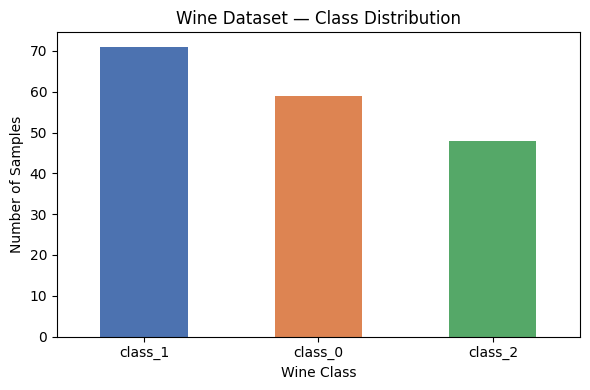

In [ ]:
# Class distribution
class_counts = df["target_name"].value_counts()
print("Class distribution:")
print(class_counts)

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar", color=["#4C72B0", "#DD8452", "#55A868"])
plt.title("Wine Dataset — Class Distribution")
plt.xlabel("Wine Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Insight:** the three classes are reasonably balanced (59, 71, and 48 samples), though not perfectly equal. This is good news for accuracy as an evaluation metric — with a more severe imbalance, accuracy alone could be misleading.


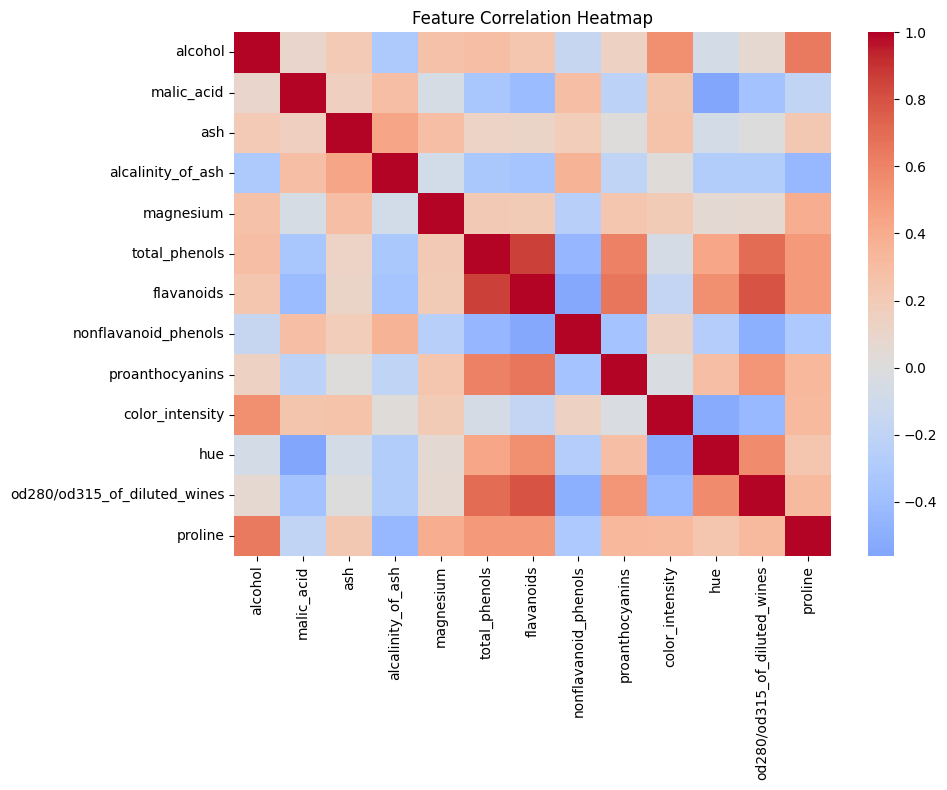

In [ ]:
# Feature correlation heatmap to understand relationships between chemical properties
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(df[feature_names].corr(), annot=False, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


In [ ]:
# Split into 80% training / 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")
print(f"Training class distribution: {np.bincount(y_train)}")
print(f"Testing class distribution:  {np.bincount(y_test)}")


Training set: 142 samples
Testing set:  36 samples
Training class distribution: [47 57 38]
Testing class distribution:  [12 14 10]


## Step 2: Implement K-Nearest Neighbors (KNN)

We train a `KNeighborsClassifier` for k = 1, 5, 11, 15, and 21, and record the test-set accuracy for each.


In [ ]:
k_values = [1, 5, 11, 15, 21]
knn_accuracies = {}

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    knn_accuracies[k] = acc
    print(f"k={k:>2}: accuracy = {acc:.4f}")


k= 1: accuracy = 0.7778
k= 5: accuracy = 0.8056
k=11: accuracy = 0.8056
k=15: accuracy = 0.8056
k=21: accuracy = 0.8056


In [ ]:
knn_results_df = pd.DataFrame({
    "k": list(knn_accuracies.keys()),
    "Accuracy": list(knn_accuracies.values())
})
knn_results_df


,k,Accuracy
0,1,0.777778
1,5,0.805556
2,11,0.805556
3,15,0.805556
4,21,0.805556


## Step 3: Implement Radius Neighbors (RNN)

We train a `RadiusNeighborsClassifier` for radius = 350, 400, 450, 500, 550, and 600, and record the test-set accuracy for each.

As noted in Step 1, these radius values are only meaningful because the data is left **unscaled** — pairwise distances between samples in the raw feature space range from about 2.6 to 1400, with a mean around 353, so a radius in the 350-600 range captures a reasonable, non-trivial neighborhood. (If the features were standardized first, typical distances would be much smaller, and these same radius values would either include almost every point or, if too small, leave many test points with no neighbors at all.)

One practical issue with RNN: if a test point happens to have **no** training points within the given radius, the classifier cannot make a prediction and raises an error by default. We guard against this with the `outlier_label` parameter, which would assign any such point to the most frequent training class instead of failing outright — and we explicitly count how many test points this fallback applies to at each radius, to see whether it's actually a factor here.


In [ ]:
radius_values = [350, 400, 450, 500, 550, 600]
rnn_accuracies = {}
rnn_no_neighbor_counts = {}

# Most frequent class in training set, used as a fallback label for any test
# point that has no training neighbors within the given radius.
majority_class = int(np.bincount(y_train).argmax())

for r in radius_values:
    rnn = RadiusNeighborsClassifier(radius=r, outlier_label=majority_class)
    rnn.fit(X_train, y_train)
    y_pred = rnn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    rnn_accuracies[r] = acc

    # Count how many test points had no neighbors within this radius
    neighbor_counts = rnn.radius_neighbors(X_test, return_distance=False)
    n_empty = sum(1 for neighbors in neighbor_counts if len(neighbors) == 0)
    rnn_no_neighbor_counts[r] = n_empty

    print(f"radius={r}: accuracy = {acc:.4f}  (test points with 0 neighbors: {n_empty}/{len(X_test)})")


radius=350: accuracy = 0.7222  (test points with 0 neighbors: 0/36)
radius=400: accuracy = 0.6944  (test points with 0 neighbors: 0/36)
radius=450: accuracy = 0.6944  (test points with 0 neighbors: 0/36)
radius=500: accuracy = 0.6944  (test points with 0 neighbors: 0/36)
radius=550: accuracy = 0.6667  (test points with 0 neighbors: 0/36)
radius=600: accuracy = 0.6667  (test points with 0 neighbors: 0/36)


In [ ]:
rnn_results_df = pd.DataFrame({
    "Radius": list(rnn_accuracies.keys()),
    "Accuracy": list(rnn_accuracies.values()),
    "Test Points With No Neighbors": list(rnn_no_neighbor_counts.values())
})
rnn_results_df


,Radius,Accuracy,Test Points With No Neighbors
0,350,0.722222,0
1,400,0.694444,0
2,450,0.694444,0
3,500,0.694444,0
4,550,0.666667,0
5,600,0.666667,0


## Step 4: Visualize and Compare Results

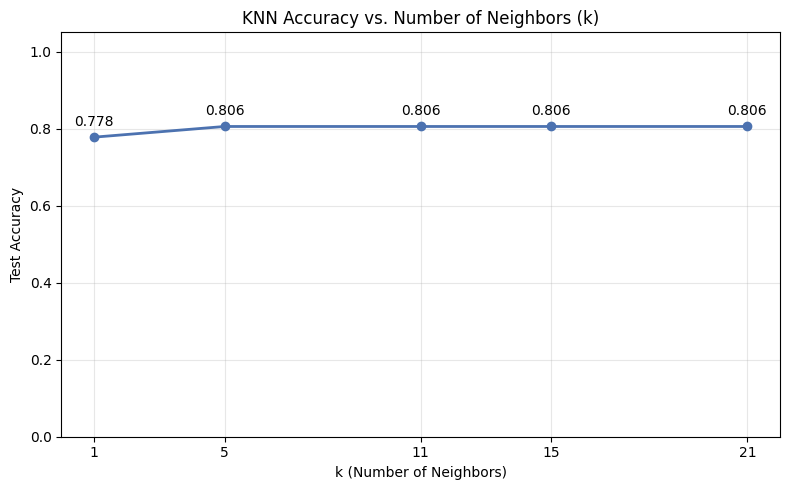

In [ ]:
# Plot: KNN accuracy vs. k
plt.figure(figsize=(8, 5))
plt.plot(list(knn_accuracies.keys()), list(knn_accuracies.values()), marker="o", color="#4C72B0", linewidth=2)
plt.title("KNN Accuracy vs. Number of Neighbors (k)")
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Test Accuracy")
plt.xticks(k_values)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
for k, acc in knn_accuracies.items():
    plt.annotate(f"{acc:.3f}", (k, acc), textcoords="offset points", xytext=(0, 8), ha="center")
plt.tight_layout()
plt.show()


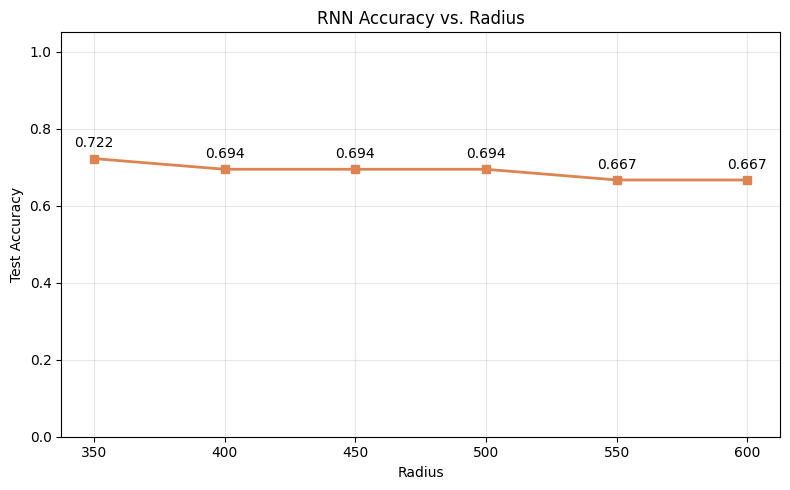

In [ ]:
# Plot: RNN accuracy vs. radius
plt.figure(figsize=(8, 5))
plt.plot(list(rnn_accuracies.keys()), list(rnn_accuracies.values()), marker="s", color="#DD8452", linewidth=2)
plt.title("RNN Accuracy vs. Radius")
plt.xlabel("Radius")
plt.ylabel("Test Accuracy")
plt.xticks(radius_values)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
for r, acc in rnn_accuracies.items():
    plt.annotate(f"{acc:.3f}", (r, acc), textcoords="offset points", xytext=(0, 8), ha="center")
plt.tight_layout()
plt.show()


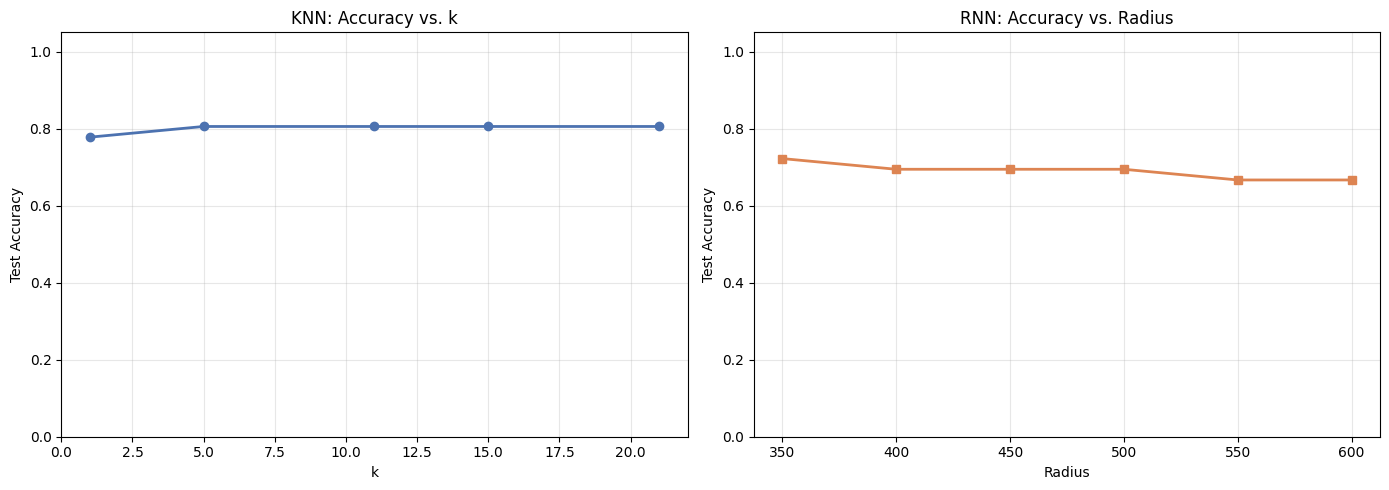

In [ ]:
# Combined comparison plot (normalized x-axis position, side by side)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(knn_accuracies.keys()), list(knn_accuracies.values()), marker="o", color="#4C72B0", linewidth=2)
axes[0].set_title("KNN: Accuracy vs. k")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Test Accuracy")
axes[0].set_ylim(0, 1.05)
axes[0].grid(alpha=0.3)

axes[1].plot(list(rnn_accuracies.keys()), list(rnn_accuracies.values()), marker="s", color="#DD8452", linewidth=2)
axes[1].set_title("RNN: Accuracy vs. Radius")
axes[1].set_xlabel("Radius")
axes[1].set_ylabel("Test Accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Summary table comparing best results from each model
best_k = max(knn_accuracies, key=knn_accuracies.get)
best_r = max(rnn_accuracies, key=rnn_accuracies.get)

summary = pd.DataFrame({
    "Model": ["KNN", "RNN"],
    "Best Parameter": [f"k={best_k}", f"radius={best_r}"],
    "Best Accuracy": [knn_accuracies[best_k], rnn_accuracies[best_r]]
})
summary


,Model,Best Parameter,Best Accuracy
0,KNN,k=5,0.805556
1,RNN,radius=350,0.722222


### Comparison and Observations

**KNN results:** accuracy is *lowest* at k=1 (0.778) and jumps up to 0.806 by k=5, then stays completely flat through k=11, k=15, and k=21. k=1 performs worst because a single nearest neighbor is a high-variance estimator — it has no way to "outvote" a mislabeled or borderline training point sitting right next to a test point. Once k reaches 5, there are enough voters to smooth out that noise, and accuracy reaches its ceiling for this dataset. The fact that accuracy does not degrade even out to k=21 (about 15% of the entire 142-sample training set) suggests the three wine classes are quite well separated along the dominant (large-scale, proline-driven) directions of this unscaled feature space, so even fairly large neighborhoods are still mostly "correct-class" neighborhoods.

**RNN results:** accuracy is *highest* at the smallest tested radius (350: 0.722) and decreases steadily as the radius grows, down to 0.667 at radius 550-600. This is the opposite of what might be assumed going in — a wider radius does not help here. Every test point had at least one neighbor even at the smallest radius tested (0 empty neighborhoods across all six radius values), so the decline isn't about points being left without a vote; it's about a larger radius pulling in more distant, less relevant training points from *other* classes and diluting the vote. Since the median pairwise distance in this unscaled feature space is about 282, every radius value tested here (350 and up) is already on the generous side, which is consistent with accuracy only getting worse as radius increases further.

**KNN vs. RNN:** KNN's best accuracy (0.806, achieved at k=5 and beyond) clearly outperforms RNN's best accuracy (0.722, at radius=350) on this dataset. The core difference is *what stays fixed*: KNN fixes the *number* of neighbors and lets the distance vary, so it automatically adapts to however dense or sparse the data is in a given region. RNN fixes the *distance* and lets the neighbor count vary, which only works well if that fixed distance means roughly the same thing everywhere in the feature space. Because this dataset is left unscaled and one feature (proline) has a much larger numeric range than the others, distances are not uniformly meaningful across the space, which is exactly the condition that hurts RNN the most.

**When to prefer KNN vs. RNN:** based on these results, KNN is the more reliable default here, precisely because it doesn't require choosing a "correct" distance threshold ahead of time — it adapts to local density automatically. RNN would likely be more competitive on a dataset with properly scaled/standardized features, or in domains where a fixed distance has real physical meaning (e.g., geospatial data measured in meters) and where explicitly flagging query points with zero nearby neighbors as outliers is itself a valuable signal. In this lab, that particular RNN strength didn't come into play, since every test point had at least one neighbor at every radius tested — but it remains a reason to consider RNN in other settings even though KNN was the stronger performer here.
